# Creating a Drug-Like CSD Subset

In this notebook, Lipinski's Rule of 5 will be applied to entries under the 'Drug' subset of the CSD (comprising all small molecule crystal structures containing FDA approved molecules) and the entire CSD. 

First, we will load all relevant packages and libraries.

In [18]:
import sys
!{sys.executable} -m pip install upsetplot venn matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45440 sha256=d1aaa73dae0e382369fc0dae555303df36b4621fb5231ca2eb6d6dabdefe3d9c
  Stored in directory: c:\users\teaching\appdata\local\pip\cache\wheels\c4\16\4a\93374cd955bbe0553a8ce74db7f0fbd5fcc876e19fb78bd601
Successfully built matplotlib-venn


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import UpSet, from_indicators
from venn import venn
from matplotlib_venn import venn2

from rdkit import Chem
from rdkit.Chem import Descriptors, QED

from ccdc import io

### Data Selection
The workflow is configured to use the CSD Drug subset for development and testing. To apply the workflow to the complete Cambridge Structural Database, comment out the Drug subset reader and uncomment the full CSD reader. No further changes to the workflow are required. 

The drug subset includes FDA approved-molecules which do not necessarily comply with Lipinski's Ro5. 

First, we extract entries from the 'Drug' subset of the CSD.

In [ ]:
# Select the dataset to analyse by uncommenting/commenting the relevant code below

# subset_name = "CSD"
subset_name = "drug"

if subset_name == "drug":
    reader = io.EntryReader(subset=io.Subsets.DRUG)
elif subset_name == "CSD":
    reader = io.EntryReader()

drug_output = Path(f"all_{subset_name}_properties.csv") # maybe change the name to lipinski_output
qed_output = Path(f"all_{subset_name}_qed_properties.csv")


Then, we use the function 'csd_iterator' to extract the molecule object for each entry within the 'Drug' subset and the SMILES string components. 

Each molecular component within a CSD entry is extracted and analysed independently. Components containing fewer than 10 heavy atoms are excluded prior to descriptor calculation. This removes small species such as counterions and solvent molecules that are unlikely to represent the primary drug-like component. Duplicate SMILES entries are disregarded.

In [5]:
# Iterate through the CSD Drug subset and extract each molecular component.
# Each component is assigned the parent CSD REFCODE together with a unique
# component identifier (e.g. ABCD01_1) to enable component-level analysis.

def csd_iterator(reader):
    """" 

    csd_iterator first extracts the molecule object for each entry then 
    the SMILES string in the database specified in the above cell.  
    It returns the identifier and the SMILES string for each molecule object.  

    """ 
    for entry in reader:
        try:
            # Extract the CSD molecule object and its associated REFCODE.
            mol = entry.molecule
            refcode = mol.identifier.strip()
            components = mol.components
        except RuntimeError:
            # Skip entries that cannot be read from the CSD.
            continue

        # Skip entries that contain no molecular components.
        if not components:
            continue

        seen = set()

        # Yield each molecular component together with the parent REFCODE,
        # a unique component identifier and its corresponding SMILES string.
        for i, component in enumerate(components, start=1):
            smiles = component.smiles
            if not smiles:
                continue

            if smiles in seen:
                continue

            seen.add(smiles)

            heavy_atom_count = sum(1 for atom in component.atoms if atom.atomic_number > 1)
            if heavy_atom_count < 10:
                continue

            yield refcode, f"{refcode}_{i}", smiles

### Calculation of Molecular Properties

We use the output from 'csd_iterator' to calculate the molecular properties (molecular weight, number of H-bond donors, number of H-bond acceptors, and Crippen logP) using RDKit for each entry.

It outputs a pandas dataframe displaying these properties coupled with the CCDC identifier (REFCODE) and the SMILES string. It exports this dataframe to a CSV file.<br>
Molecules for which RDKit has failed to calculate properties
are output into a separate CSV file. 

In [ ]:
# Initialise lists to store successfully processed components and any
# components that fail during processing.
lipinski_records = []
qed_records = []
failed_records = []

# Iterate through each molecular component extracted from the CSD Drug subset.
for refcode, component_refcode, smiles in csd_iterator(reader):

    # Skip components with no available SMILES string and record the failure.
    if not smiles:
        failed_records.append({
            "refcode": refcode,
            "component_refcode": component_refcode,
            "stage": "missing_smiles",
            "error": "No SMILES available"
        })
        continue

    # Convert the SMILES string into an RDKit molecule object.
    mol = Chem.MolFromSmiles(smiles)

    # Record components that RDKit cannot successfully parse.
    if mol is None:
        failed_records.append({
            "refcode": refcode,
            "component_refcode": component_refcode,
            "stage": "smiles_parse",
            "error": "RDKit could not parse SMILES"
        })
        continue

    # Calculate the molecular descriptors required for Lipinski's Rule of Five.
    lipinski_records.append({
        "refcode": refcode,
        "component_refcode": component_refcode,
        "smiles": smiles,
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "logP": Descriptors.MolLogP(mol),
        "MW": Descriptors.ExactMolWt(mol),
    })

    # Calculate the molecular descriptors required for the QED score.
    qed_descriptors = QED.properties(mol)
    qed_records.append({
        "refcode": refcode,
        "component_refcode": component_refcode,
        "smiles": smiles,
        **qed_descriptors._asdict(),
        "QED": QED.qed(mol, qedProperties=qed_descriptors)
    })


# Convert the results into pandas DataFrames.
lipinski_df = pd.DataFrame(lipinski_records)
qed_df = pd.DataFrame(qed_records)
failed_df = pd.DataFrame(failed_records)

# Save the successfully analysed components and failed components to
# separate CSV files.
lipinski_df.to_csv(drug_output, index=False)
qed_df.to_csv(qed_output, index=False)
failed_df.to_csv(f"failed_{subset_name}_properties.csv", index=False)

# Report the number of components successfully analysed.
print(f"Successfully analysed components with Lipinski: {len(lipinski_df)}")
print(f"Successfully analysed components with QED: {len(qed_df)}")

[15:34:14] Explicit valence for atom # 0 C, 5, is greater than permitted
[15:34:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[15:34:16] Explicit valence for atom # 5 C, 5, is greater than permitted
[15:34:16] Explicit valence for atom # 5 C, 5, is greater than permitted
[15:34:16] Explicit valence for atom # 6 C, 5, is greater than permitted
[15:34:16] Explicit valence for atom # 6 C, 5, is greater than permitted
[15:34:16] Explicit valence for atom # 6 C, 5, is greater than permitted
[15:34:17] Explicit valence for atom # 35 C, 5, is greater than permitted
[15:34:17] Explicit valence for atom # 4 N, 4, is greater than permitted
[15:34:17] Explicit valence for atom # 0 O, 3, is greater than permitted
[15:34:18] Explicit valence for atom # 1 Te, 8, is greater than permitted
[15:34:20] Explicit valence for atom # 4 C, 5, is greater than permitted
[15:34:20] Explicit valence for atom # 3 B, 4, is greater than permitted
[15:34:20] Explicit valence for atom # 3 B, 4, is

Successfully analysed components with Lipinski: 19193
Successfully analysed components with QED: 19193


lipinski_df = pandas dataframe listing the entries of the 'Drug' subset of the CSD alongside their (Lipinski) molecular properties

In [7]:
lipinski_df.head()

,refcode,component_refcode,smiles,HBD,HBA,logP,MW
0,ABABIQ,ABABIQ_3,COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(=O)C(=CN(C3C...,2,5,1.34430,402.182361
1,ABADOY,ABADOY_1,[NH3+]c1ccc(cc1)S(N)(=O)=O,2,2,-0.79260,173.037925
2,ABAJAQ,ABAJAQ_1,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-],0,6,0.64800,285.961677
3,ABAQEB,ABAQEB_1,OC(=O)C1CCCCC1C(=O)[O-],1,3,-0.37270,171.066282
4,ABAZUB,ABAZUB_2,COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)C...,1,8,5.19038,529.164745


qed_df = pandas dataframe listing the entries of the 'Drug' subset of the CSD alongside their (QED) molecular properties

In [9]:
qed_df.head()

,refcode,component_refcode,smiles,MW,ALOGP,HBA,HBD,PSA,ROTB,AROM,ALERTS,QED
0,ABABIQ,ABABIQ_3,COc1c(N2CC3[NH2+]CCCC3C2)c(F)cc2C(=O)C(=CN(C3C...,402.446,1.34430,5,2,88.38,4,2,0,0.806013
1,ABADOY,ABADOY_1,[NH3+]c1ccc(cc1)S(N)(=O)=O,173.217,-0.79260,2,2,87.80,1,1,0,0.582433
2,ABAJAQ,ABAJAQ_1,O=S(=O)([O-])c1cccc2c1cccc2S(=O)(=O)[O-],286.286,0.64800,6,0,114.40,2,2,1,0.748428
3,ABAQEB,ABAQEB_1,OC(=O)C1CCCCC1C(=O)[O-],171.172,-0.37270,4,1,77.43,2,0,0,0.614341
4,ABAZUB,ABAZUB_2,COc1cc(Nc2c(cnc3cc(OCCCN4CCN(C)CC4)c(OC)cc23)C...,530.456,5.19038,8,1,82.88,9,3,1,0.378829


failed_df = pandas dataframe listing the entries of the 'Drug' subset of the CSD for which RDKit could not calculate the molecular properties.

In [8]:
failed_df.head()

,refcode,component_refcode,stage,error
0,AFOPET,AFOPET_4,smiles_parse,RDKit could not parse SMILES
1,AJUKUL,AJUKUL_4,smiles_parse,RDKit could not parse SMILES
2,APOPEB,APOPEB_4,smiles_parse,RDKit could not parse SMILES
3,APOPIF,APOPIF_3,smiles_parse,RDKit could not parse SMILES
4,APOQOM,APOQOM_5,smiles_parse,RDKit could not parse SMILES


### Rule of five analysis:

The calculated molecular descriptors are compared against the Lipinski Rule of Five thresholds. Each molecule is assigned a binary pass/fail value for each rule. These values are summed to determine how many of the four criteria each molecule satisfies, and summary statistics are generated to describe the distribution across the dataset.

Components satisfying at least three of the four criteria are classified as drug-like.

Finally, parent CCDC refcodes corresponding to drug-like components are identified and listed in a .gcd file for use within CCDC software.

In [ ]:
# Apply Lipinski Rule of Five thresholds
thresholds = {
    'HBD': 5,
    'HBA': 10,
    'logP': 5,
    'MW': 500
}

# Create binary pass/fail columns for each descriptor
for col, thresh in thresholds.items():
    lipinski_df[f'{col}_bin'] = (lipinski_df[col] <= thresh).astype(int)

# Calculate the number of Rule of Five criteria satisfied
bin_cols = ['HBD_bin', 'HBA_bin', 'logP_bin', 'MW_bin']
lipinski_df['bin_sum'] = lipinski_df[bin_cols].sum(axis=1)

# Components satisfying at least three of the four criteria
lipinski_df["drug_like"] = lipinski_df["bin_sum"] >= 3

# REFCODEs where at least one component satisfies all four criteria
refcodes_all_4 = (
    lipinski_df.loc[lipinski_df["bin_sum"] == 4, "refcode"]
      .drop_duplicates()
      .sort_values()
)

# REFCODEs where at least one component satisfies three or more criteria
refcodes_at_least_3 = (
    lipinski_df.loc[lipinski_df["bin_sum"] >= 3, "refcode"]
      .drop_duplicates()
      .sort_values()
)

# Export the stricter Rule of Five subset
with Path(f"{subset_name}_drug_like_refcodes_all_4.gcd").open("w") as f:
    for refcode in refcodes_all_4:
        f.write(f"{refcode}\n")

# Export the more permissive Rule of Five subset
with Path(f"{subset_name}_drug_like_refcodes_at_least_3.gcd").open("w") as f:
    for refcode in refcodes_at_least_3:
        f.write(f"{refcode}\n")

print(f"REFCODEs satisfying all four criteria: {len(refcodes_all_4)}")
print(f"REFCODEs satisfying at least three criteria: {len(refcodes_at_least_3)}")

REFCODEs satisfying all four criteria: 13251
REFCODEs satisfying at least three criteria: 13992


### QED analysis

The QED (Quantitative Estimate of Drug-likeness) score for each successfully analysed molecular component is compared against a user-defined threshold, entered interactively when this cell is run (default 0.6 if left blank). Unlike the Lipinski Rule of Five, QED combines multiple physicochemical descriptors into a single continuous score between 0 and 1, with higher values indicating greater drug-likeness.

Components with a QED score at or above the threshold are identified, and the parent CCDC REFCODEs corresponding to these components are extracted, deduplicated, and listed in a `.gcd` file for use within CCDC software (analogous to the Lipinski Rule of Five REFCODE exports above).

In [16]:
# Ask the user to define a QED threshold between 0 and 1 (default 0.6 if left blank)
qed_threshold_input = input("Enter QED threshold (0-1, default 0.6): ").strip()

if qed_threshold_input == "":
    qed_threshold = 0.6
else:
    qed_threshold = float(qed_threshold_input)

if not 0 <= qed_threshold <= 1:
    raise ValueError("QED threshold must be between 0 and 1.")

# REFCODEs of components with a QED score at or above the threshold
qed_drug_like_refcodes = (
    qed_df.loc[qed_df["QED"] >= qed_threshold, "refcode"]
      .drop_duplicates()
      .sort_values()
)

# Export the REFCODEs satisfying the QED filter
with Path(f"{subset_name}_drug_like_refcodes_qed_{qed_threshold}.gcd").open("w") as f:
    for refcode in qed_drug_like_refcodes:
        f.write(f"{refcode}\n")

print(f"REFCODEs satisfying QED >= {qed_threshold}: {len(qed_drug_like_refcodes)}")

REFCODEs satisfying QED >= 0.5: 11206


### Lipinski vs QED Comparison

We compare drug-likeness as assessed by the Lipinski Rule of Five against drug-likeness as assessed by the QED score, at the level of the **parent CSD REFCODE** rather than the individual molecular component.

A parent REFCODE is classified as:
- **Lipinski-positive** if at least one of its components satisfies at least 3 of the 4 Rule of Five criteria (`refcodes_at_least_3`)
- **QED-positive** if at least one of its components has a QED score at or above the user-defined threshold (`qed_drug_like_refcodes`)

We report the percentage of the whole RDKit-parsed dataset (unique parent REFCODEs) satisfying each criterion separately, split REFCODEs into "Lipinski only", "QED only" and "Both" categories, export each category to a `.gcd` file, and visualise the overlap as a 2-set Venn diagram. Venn diagram percentages are expressed relative to the total number of parsed REFCODEs in the dataset, not relative to the union of the two sets shown.

Total parent REFCODEs (successfully parsed by RDKit): 14608
REFCODEs with >=1 component satisfying >=3 Lipinski criteria: 13992 (95.78%)
REFCODEs with >=1 component satisfying QED >= 0.5: 11206 (76.71%)

REFCODEs satisfying both criteria: 11205
REFCODEs satisfying Lipinski only: 2787
REFCODEs satisfying QED only: 1


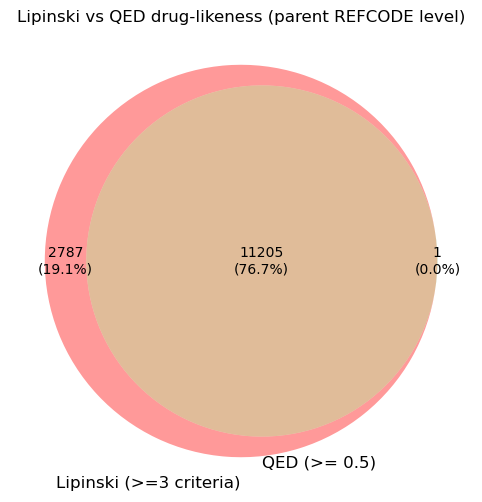

In [20]:
# --- Step 1: Total dataset size (unique parent REFCODEs successfully parsed by RDKit) ---
total_refcodes = lipinski_df["refcode"].drop_duplicates()
total_refcodes_count = len(total_refcodes)

# --- Step 2: Parent-level pass sets (reusing refcodes_at_least_3 and qed_drug_like_refcodes) ---
lipinski_pass_refcodes = set(refcodes_at_least_3)
qed_pass_refcodes = set(qed_drug_like_refcodes)

# --- Step 3: Percentage of dataset satisfying each criterion (parent REFCODE level) ---
lipinski_pass_pct = 100 * len(lipinski_pass_refcodes) / total_refcodes_count
qed_pass_pct = 100 * len(qed_pass_refcodes) / total_refcodes_count

print(f"Total parent REFCODEs (successfully parsed by RDKit): {total_refcodes_count}")
print(f"REFCODEs with >=1 component satisfying >=3 Lipinski criteria: "
      f"{len(lipinski_pass_refcodes)} ({lipinski_pass_pct:.2f}%)")
print(f"REFCODEs with >=1 component satisfying QED >= {qed_threshold}: "
      f"{len(qed_pass_refcodes)} ({qed_pass_pct:.2f}%)")

# --- Step 4: Compare the two REFCODE-level sets ---
both_refcodes = sorted(lipinski_pass_refcodes & qed_pass_refcodes)
lipinski_only_refcodes = sorted(lipinski_pass_refcodes - qed_pass_refcodes)
qed_only_refcodes = sorted(qed_pass_refcodes - lipinski_pass_refcodes)

print(f"\nREFCODEs satisfying both criteria: {len(both_refcodes)}")
print(f"REFCODEs satisfying Lipinski only: {len(lipinski_only_refcodes)}")
print(f"REFCODEs satisfying QED only: {len(qed_only_refcodes)}")

# --- Step 5: Export each category to a .gcd file ---
def write_gcd(refcodes, filename):
    with Path(filename).open("w") as f:
        for refcode in refcodes:
            f.write(f"{refcode}\n")

write_gcd(both_refcodes, f"{subset_name}_refcodes_both_lipinski_qed.gcd")
write_gcd(lipinski_only_refcodes, f"{subset_name}_refcodes_lipinski_only.gcd")
write_gcd(qed_only_refcodes, f"{subset_name}_refcodes_qed_only.gcd")

# --- Step 6: Venn diagram with percentages relative to the whole dataset ---
plt.figure(figsize=(6, 6))

v = venn2(
    subsets=(len(lipinski_only_refcodes), len(qed_only_refcodes), len(both_refcodes)),
    set_labels=("Lipinski (>=3 criteria)", f"QED (>= {qed_threshold})")
)

# Overwrite each region's label with count + percentage of the whole dataset
label_data = {
    "10": len(lipinski_only_refcodes),
    "01": len(qed_only_refcodes),
    "11": len(both_refcodes),
}
for region_id, count in label_data.items():
    label = v.get_label_by_id(region_id)
    if label is not None:
        pct = 100 * count / total_refcodes_count
        label.set_text(f"{count}\n({pct:.1f}%)")

plt.title("Lipinski vs QED drug-likeness (parent REFCODE level)")
plt.show()

### Output:

This notebook generates:

- `all_drug_properties.csv`: molecular descriptors (MW, HBD, HBA and logP) for successfully analysed molecular components.
- `all_drug_qed_properties.csv`: QED descriptors and overall QED score for successfully analysed molecular components.
- `failed_drug_properties.csv`: components that could not be processed by RDKit, together with the stage at which processing failed.
- `drug_like_refcodes_all_4.gcd`: unique CSD REFCODEs containing at least one molecular component satisfying all four Lipinski Rule of Five criteria.
- `drug_like_refcodes_at_least_3.gcd`: unique CSD REFCODEs containing at least one molecular component satisfying at least three of the four Lipinski Rule of Five criteria (allowing one violation).
- `drug_like_refcodes_qed_<threshold>.gcd`: unique CSD REFCODEs containing at least one molecular component with a QED score at or above the user-defined threshold.
- `lipinski_qed_overlap.csv`: component-level comparison of Lipinski vs QED pass/fail status, restricted to components passing at least one of the two criteria.
- `refcodes_both_lipinski_qed.gcd`: unique parent REFCODEs satisfying both the Lipinski (≥3 criteria) and QED drug-likeness definitions.
- `refcodes_lipinski_only.gcd`: unique parent REFCODEs satisfying the Lipinski definition only.
- `refcodes_qed_only.gcd`: unique parent REFCODEs satisfying the QED definition only.

# Comparative Analysis
### Multi-Component Entries

We can investigate multi-component entries by separating the components into different entries and determining the molecular properties for each entry. The resulting dataframe is then exported to a CSV file. 

In [ ]:
whole_entry_records = []

for entry in reader:
    try:
        mol = entry.molecule
        refcode = mol.identifier.strip()
        smiles = mol.smiles
    except RuntimeError:
        continue

    # Only keep multicomponent entries
    if not smiles or "." not in smiles:
        continue

    rdkit_mol = Chem.MolFromSmiles(smiles)
    if rdkit_mol is None:
        continue

    whole_entry_records.append({
        "refcode": refcode,
        "smiles": smiles,
        "HBD": Descriptors.NumHDonors(rdkit_mol),
        "HBA": Descriptors.NumHAcceptors(rdkit_mol),
        "logP": Descriptors.MolLogP(rdkit_mol),
        "MW": Descriptors.ExactMolWt(rdkit_mol),
    })

whole_entry_df = pd.DataFrame(whole_entry_records)
whole_entry_df.to_csv("{subset_name}_whole_multicomponent_properties.csv", index=False)

We then compare the means for the different physicochemical properties between the multi-component entries and the individual components of the multi-component entries.

In [ ]:
comparison = pd.DataFrame({
    "Whole entry": whole_entry_df[["HBD", "HBA", "logP", "MW"]].mean(),
    "Components": lipinski_df[["HBD", "HBA", "logP", "MW"]].mean()
})

comparison

## Data visualisation 
Below is code which can be run to visualise data outputs.

1. Create a table to show how many entries are conforming to all, 3, 2 or 1 rules

In [ ]:
#row_summary = (csd_df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary = (lipinski_df["bin_sum"].value_counts().reindex([4,3,2,1,0], fill_value=0).to_frame(name="count"))
row_summary["percent"] = 100 * row_summary["count"] / row_summary["count"].sum()

row_summary["percent"] = row_summary["percent"].round(2)

row_summary

2. We Can check that the total number of entries is the same in our table in the above cell and in our dataframe. 

In [ ]:
#row_summary["count"].sum() == len(csd_df)
row_summary["count"].sum() == len(lipinski_df)

3. We also generate a table to show the number of entries satisfying each Ro5 condition.

In [ ]:
#col_summary = csd_df[bin_cols].sum().to_frame(name="count")
col_summary = lipinski_df[bin_cols].sum().to_frame(name="count")

#col_summary["percent"] = 100 * col_summary["count"] / len(csd_df)
col_summary["percent"] = 100 * col_summary["count"] / len(lipinski_df)

col_summary["percent"] = col_summary["percent"].round(2)

col_summary

In [ ]:
for c in bin_cols:
    print(c, lipinski_df[c].value_counts(dropna=False))

5. Next, we can visualise our findings as a 4-set Venn diagram.

In [ ]:
total_rows = len(lipinski_df)
in_any_set = lipinski_df[bin_cols].fillna(0).astype(bool).any(axis=1).sum()
four_way = lipinski_df[bin_cols].fillna(0).astype(bool).all(axis=1).sum()

print("Total rows:", total_rows)
print("Rows in any set:", in_any_set)
print("4-way intersection:", four_way)
print("4-way as % of all rows:", 100 * four_way / total_rows)
print("4-way as % of union of sets:", 100 * four_way / in_any_set)

In [ ]:
#sets = {c: set(csd_df.index[df[c] == 1]) for c in bin_cols}
sets = {c: set(lipinski_df.index[lipinski_df[c] == 1]) for c in bin_cols}
plt.figure(figsize=(8, 8))

v = venn(sets, fmt="{size}\n({percentage:.1f}%)")
plt.title("Elliptical-style 4-set Venn")
plt.show()

6) We then generate an UpSet plot to visualise the combinations of properties that satisfy the Ro5.

In [ ]:
print(lipinski_df.isna().sum())

In [ ]:
lipinski_df.isna().sum()
lipinski_df[lipinski_df.isna().any(axis=1)]

In [ ]:
lipinski_df.head()

In [ ]:
bin_cols = ["HBD_bin", "HBA_bin", "logP_bin", "MW_bin"]

#csd_df[bin_cols] = csd_df[bin_cols].fillna(0).astype(int)
lipinski_df[bin_cols] = lipinski_df[bin_cols].fillna(0).astype(int)

#csd_df[bin_cols] = csd_df[bin_cols].fillna(0).astype(bool)
clean_df = lipinski_df[bin_cols].fillna(0).astype(bool)

#data = from_indicators(bin_cols, csd_df)
data = from_indicators(clean_df)

plt.figure(figsize=(10, 6))
up = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality"
)

up.plot()
plt.suptitle("UpSet plot for properties", y=1.02)
plt.show()